# Micro-organism Object Detection — R-CNN, Fast R-CNN, and Faster R-CNN

**Goal:** Every notebook so far in this project has done *classification* — "which one of 8 types
is this image?" This notebook does something genuinely different: **object detection** — "**where**
in this image is the micro-organism, and what type is it?" The answer isn't one label anymore, it's
a **bounding box** (a rectangle) *plus* a label.

This notebook builds, trains, and runs all **three** of the classic R-CNN-family detectors, in order,
so you can see exactly what each one improved on the last:

- **Part A — R-CNN** (Girshick et al., 2014): the original. Propose ~hundreds of candidate regions,
  then run a full CNN on **each one separately**.
- **Part B — Fast R-CNN** (Girshick, 2015): run the CNN **once** on the whole image, then pool
  features for each candidate region out of that single shared feature map.
- **Part C — Faster R-CNN** (Ren et al., 2015): replace the (slow, hand-engineered) region-proposal
  step itself with a small trainable neural network.

Every piece of real detection theory is implemented here — region proposals, IoU, bounding-box
regression, ROI Pooling, anchors, a Region Proposal Network, Non-Maximum Suppression — nothing is
hand-waved away. A few deliberate, clearly-flagged simplifications keep the code readable for a
first pass (noted exactly where they happen); none of them hide how the actual algorithms work.

**An important, honest note on the dataset.** Your micro-organism folders have one label *per whole
image* — there are no bounding box annotations, because that dataset was built for classification,
not detection. Object detection absolutely needs "the object is at these pixel coordinates" labels
to train on. Step 4 below solves this the way you'd actually solve it in practice when you only have
classification images: we build our **own** small detection dataset by pasting a real micro-organism
photo onto a larger blank canvas at a random position — since *we* chose where to paste it, we know
the exact ground-truth bounding box with no manual annotation needed at all.

## Step 1: Import the Libraries

A few new imports this time:
- `cv2` (OpenCV) — specifically `cv2.ximgproc.segmentation`, which provides **Selective Search**,
  the region-proposal algorithm the original R-CNN and Fast R-CNN papers both used.
- `random` — for choosing random paste positions and random proposal subsets.
- `time` — to actually *measure* the speed difference between the three methods later on, instead of
  just talking about it.

In [1]:
# Basic Python tools
import os
import random
import time
from pathlib import Path

# Numerical operations and image handling
import numpy as np
import cv2

# For plotting images, boxes, and graphs
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Deep learning library
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Dense, Dropout, Flatten, Layer
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

print("TensorFlow version:", tf.__version__)
print("OpenCV version:", cv2.__version__)

# A fixed seed everywhere in this notebook
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version: 2.20.0
OpenCV version: 4.14.0


## Step 2: Set the Dataset Path and Basic Parameters

- `CANVAS_SIZE` — the size of the larger synthetic "scene" we paste each micro-organism photo onto
  (224x224, same as every other notebook in this project).
- `OBJECT_SIZE_MIN` / `OBJECT_SIZE_MAX` — each pasted organism is randomly resized to somewhere in
  this range before being placed, so the detector has to cope with objects of different sizes, not
  just one fixed size.
- `IOU_POSITIVE_THRESHOLD` / `IOU_NEGATIVE_THRESHOLD` — how we'll decide whether a candidate region
  "is" the object (high overlap with the true box) or "is" background (low overlap) — more on this
  in Step 6.
- `NUM_PROPOSALS_PER_IMAGE` — how many Selective Search proposals we keep per image for R-CNN and
  Fast R-CNN (Parts A and B).
- Faster R-CNN's own anchor settings are introduced later, in Part C, where they're first used.

**Important:** Update `DATASET_DIR` below if your folder path is different.

In [2]:
# Path to the main dataset folder (one sub-folder per micro-organism type).
from google.colab import drive
drive.mount('/content/drive')

# Then update your dataset path to point to Drive
DATASET_DIR = Path("/content/drive/MyDrive/Colab Notebooks/Micro_Organism")

# The size of the synthetic "scene" each object gets pasted into
CANVAS_SIZE = 224

# Each pasted object is randomly resized to somewhere in this range (pixels, on each side)
OBJECT_SIZE_MIN = 60
OBJECT_SIZE_MAX = 110

# A candidate region counts as "the object" if it overlaps the true box by at least this much,
# and counts as "background" if it overlaps by less than this much (see Step 6)
IOU_POSITIVE_THRESHOLD = 0.5
IOU_NEGATIVE_THRESHOLD = 0.3

# How many Selective Search proposals to keep per image for Parts A and B
NUM_PROPOSALS_PER_IMAGE = 200

# How many proposals to actually train on per image (a balanced mix of object / background --
# training on all ~200 would be slow and heavily background-biased, so, exactly like the original
# papers, we sample a small, balanced batch instead)
PROPOSALS_PER_IMAGE_FOR_TRAINING = 32

# Fixed input size every cropped region gets resized ("warped") to before going into the CNN
ROI_SIZE = 64

SEED_SPLIT = 42
VALIDATION_SPLIT = 0.2

Mounted at /content/drive


## Step 3: Explore the Dataset

Same exploration as every other notebook in this project — check the micro-organism types and how
many photos of each one we have to work with.

In [3]:
class_names = sorted([folder.name for folder in DATASET_DIR.iterdir() if folder.is_dir()])
num_classes = len(class_names)

print("Number of micro-organism types (classes) found:", num_classes)
for name in class_names:
    print(" -", name)

all_image_paths = []   # every image file path, together with its class label
all_image_labels = []

for class_index, class_name in enumerate(class_names):
    class_folder = DATASET_DIR / class_name
    image_files = [f for f in class_folder.iterdir() if f.suffix.lower() in [".jpg", ".jpeg", ".png"]]
    for f in image_files:
        all_image_paths.append(f)
        all_image_labels.append(class_index)

print("\nTotal images found:", len(all_image_paths))

Number of micro-organism types (classes) found: 8
 - Amoeba
 - Euglena
 - Hydra
 - Paramecium
 - Rod_bacteria
 - Spherical_bacteria
 - Spiral_bacteria
 - Yeast

Total images found: 789


## Step 4: Build a Synthetic Object-Detection Dataset

As explained at the top of this notebook, we don't have bounding-box annotations — so we make our
own small, perfectly-labeled detection dataset out of the classification images we do have. For
every photo:

1. Load the real micro-organism image.
2. Resize it to a random size between `OBJECT_SIZE_MIN` and `OBJECT_SIZE_MAX` pixels.
3. Create a plain, lightly-noisy `CANVAS_SIZE x CANVAS_SIZE` background.
4. Paste the resized photo onto the canvas at a **random** valid position.
5. Record the exact `[x1, y1, x2, y2]` pixel coordinates of where we just pasted it — this is now
   our **ground-truth bounding box**, known exactly, because we chose it ourselves.

**One deliberate simplification, clearly flagged:** each synthetic scene contains exactly **one**
object. Real photos (and real R-CNN/Fast R-CNN/Faster R-CNN use cases) usually have several objects
per image — all three architectures handle that case too, with no change to the core ideas, but
starting with one object per scene keeps the bookkeeping in every step below much easier to follow.

In [4]:
def build_synthetic_scene(image_path, canvas_size=CANVAS_SIZE):
    """Loads one real micro-organism photo and pastes it onto a larger canvas at a random
    position, returning the finished scene plus the ground-truth bounding box.
    """
    # Load the real photo and make sure it's in RGB (OpenCV loads as BGR by default)
    original = cv2.imread(str(image_path))
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

    # Resize it to a random object size
    object_size = random.randint(OBJECT_SIZE_MIN, OBJECT_SIZE_MAX)
    object_img = cv2.resize(original, (object_size, object_size))

    # A plain, lightly-noisy gray background to paste onto
    canvas = np.random.normal(loc=180, scale=8, size=(canvas_size, canvas_size, 3))
    canvas = np.clip(canvas, 0, 255).astype(np.uint8)

    # Choose a random top-left corner so the whole object fits inside the canvas
    max_x = canvas_size - object_size
    max_y = canvas_size - object_size
    x1 = random.randint(0, max_x)
    y1 = random.randint(0, max_y)
    x2 = x1 + object_size
    y2 = y1 + object_size

    # Paste the object onto the canvas
    canvas[y1:y2, x1:x2] = object_img

    ground_truth_box = [x1, y1, x2, y2]
    return canvas, ground_truth_box

In [5]:
# Build the full synthetic detection dataset: one scene per real photo
scene_images = []
scene_boxes = []
scene_labels = []

for path, label in zip(all_image_paths, all_image_labels):
    canvas, box = build_synthetic_scene(path)
    scene_images.append(canvas)
    scene_boxes.append(box)
    scene_labels.append(label)

scene_images = np.array(scene_images, dtype=np.uint8)
scene_boxes = np.array(scene_boxes, dtype=np.float32)
scene_labels = np.array(scene_labels, dtype=np.int32)

print("Synthetic scenes built:", len(scene_images))
print("scene_images shape:", scene_images.shape)
print("scene_boxes shape:  ", scene_boxes.shape)

Synthetic scenes built: 789
scene_images shape: (789, 224, 224, 3)
scene_boxes shape:   (789, 4)


In [6]:
# Split into training and validation sets (same random split for every part of this notebook)
num_scenes = len(scene_images)
indices = np.arange(num_scenes)
rng = np.random.default_rng(SEED_SPLIT)
rng.shuffle(indices)

split_point = int(num_scenes * (1 - VALIDATION_SPLIT))
train_indices = indices[:split_point]
val_indices = indices[split_point:]

train_images, val_images = scene_images[train_indices], scene_images[val_indices]
train_boxes, val_boxes = scene_boxes[train_indices], scene_boxes[val_indices]
train_labels, val_labels = scene_labels[train_indices], scene_labels[val_indices]

print("Training scenes:  ", len(train_images))
print("Validation scenes:", len(val_images))

Training scenes:   631
Validation scenes: 158


## Step 5: Visualize Sample Detection Images

A quick visual check — the green rectangle is the ground-truth box we just generated in Step 4.

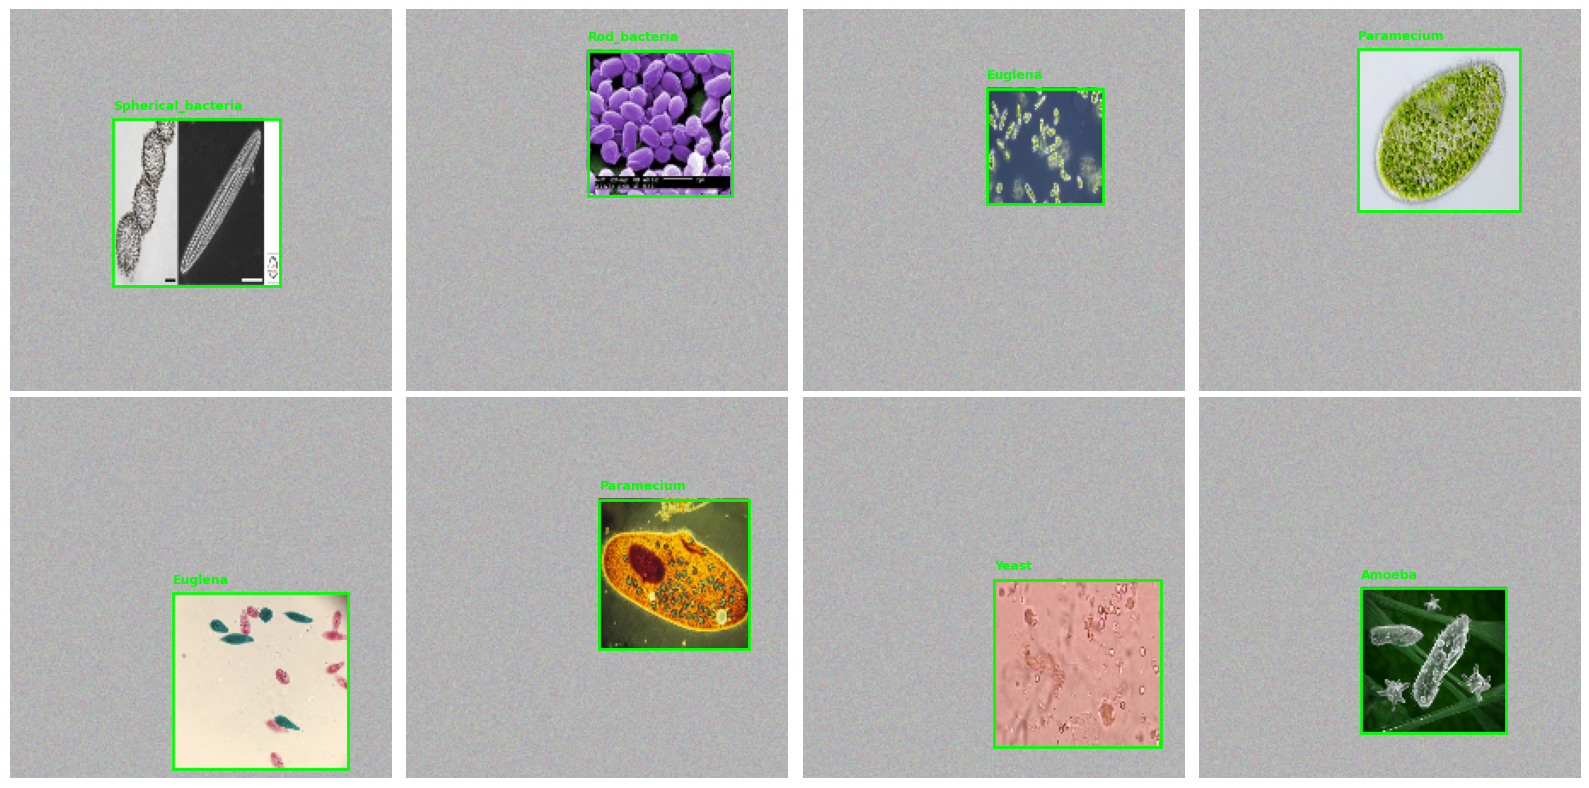

In [7]:
def show_image_with_box(ax, image, box, label_text=None, box_color="lime"):
    """Draws one image with a bounding box rectangle on top of it, on a given matplotlib axis."""
    ax.imshow(image)
    x1, y1, x2, y2 = box
    rect = patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor=box_color, facecolor="none"
    )
    ax.add_patch(rect)
    if label_text is not None:
        ax.text(x1, max(y1 - 6, 0), label_text, color=box_color, fontsize=9, weight="bold")
    ax.axis("off")


fig, axes = plt.subplots(2, 4, figsize=(16, 8))
sample_indices = random.sample(range(len(train_images)), 8)

for ax, idx in zip(axes.flat, sample_indices):
    class_name = class_names[train_labels[idx]]
    show_image_with_box(ax, train_images[idx], train_boxes[idx], label_text=class_name)

plt.tight_layout()
plt.show()

## Step 6: Shared Toolbox — IoU and Non-Maximum Suppression

Two small functions every single part of this notebook (R-CNN, Fast R-CNN, and Faster R-CNN) relies
on, so we build them once, upfront, and reuse them everywhere below.

**Intersection over Union (IoU)** answers one question: *"how much do two boxes overlap?"* It's the
area where both boxes overlap, divided by the total area the two boxes cover between them. IoU of 1
means identical boxes; IoU of 0 means no overlap at all. We'll use IoU for two different jobs later:
*labeling* candidate regions during training ("does this candidate region overlap the true object
enough to count as a match?"), and *cleaning up* predictions during inference (next function).

**Non-Maximum Suppression (NMS)** solves a different problem: a detector will almost always fire
*multiple* overlapping candidate boxes on the *same* real object, each with its own confidence score.
NMS keeps only the highest-confidence box for each object and throws away the other boxes that
overlap it too much, leaving one clean box per detected object instead of a cluttered pile of
near-duplicates.

In [8]:
def compute_iou(box1, box2):
    """IoU between two boxes, each as [x1, y1, x2, y2]."""
    xA = max(box1[0], box2[0])
    yA = max(box1[1], box2[1])
    xB = min(box1[2], box2[2])
    yB = min(box1[3], box2[3])

    inter_width = max(0, xB - xA)
    inter_height = max(0, yB - yA)
    intersection = inter_width * inter_height

    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection

    return intersection / union if union > 0 else 0.0


def compute_iou_batch(boxes, single_box):
    """Vectorized IoU between many boxes (an array of shape (N, 4)) and one box -- much faster
    than calling compute_iou() in a Python loop when N is large (e.g. hundreds of proposals or
    thousands of anchors).
    """
    x1 = np.maximum(boxes[:, 0], single_box[0])
    y1 = np.maximum(boxes[:, 1], single_box[1])
    x2 = np.minimum(boxes[:, 2], single_box[2])
    y2 = np.minimum(boxes[:, 3], single_box[3])

    inter_w = np.clip(x2 - x1, 0, None)
    inter_h = np.clip(y2 - y1, 0, None)
    intersection = inter_w * inter_h

    area_boxes = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
    area_single = (single_box[2] - single_box[0]) * (single_box[3] - single_box[1])
    union = area_boxes + area_single - intersection

    return intersection / np.clip(union, 1e-9, None)


def non_max_suppression(boxes, scores, iou_threshold=0.3):
    """Given a list of boxes and their confidence scores, returns the indices of the boxes to
    keep: always keep the highest-scoring remaining box, throw away every other box that overlaps
    it by more than iou_threshold, and repeat until nothing is left to consider.
    """
    if len(boxes) == 0:
        return []

    boxes = np.array(boxes, dtype=np.float32)
    order = np.argsort(scores)[::-1]  # indices sorted from highest score to lowest
    keep = []

    while len(order) > 0:
        current = order[0]
        keep.append(current)

        remaining_boxes = boxes[order[1:]]
        if len(remaining_boxes) == 0:
            break
        ious = compute_iou_batch(remaining_boxes, boxes[current])

        order = order[1:][ious < iou_threshold]

    return keep

One more shared tool: **bounding-box regression encoding**. A candidate region is almost never a
*perfect* match for the true object box — it's usually close, but shifted or a slightly different
size. Rather than ask a neural network to predict raw pixel coordinates directly (hard to learn,
since the "right answer" changes completely depending on where the object happens to be), every part
of this notebook instead predicts a small *adjustment*: how to nudge a candidate box's center and
how to rescale its width/height to line it up with the true box. `encode_box_target` computes that
adjustment during training (we already know the true box, so we can compute the exact target);
`decode_box_prediction` does the reverse at prediction time, turning the network's predicted
adjustment back into actual pixel coordinates.

In [9]:
def encode_box_target(candidate_box, ground_truth_box):
    """Computes the (tx, ty, tw, th) adjustment that would turn candidate_box into
    ground_truth_box: tx/ty shift the center (as a fraction of the candidate's own width/height),
    tw/th rescale the width/height (in log-space, so doubling and halving are symmetric).
    """
    cx1, cy1, cx2, cy2 = candidate_box
    gx1, gy1, gx2, gy2 = ground_truth_box

    c_width, c_height = cx2 - cx1, cy2 - cy1
    c_center_x, c_center_y = cx1 + c_width / 2, cy1 + c_height / 2

    g_width, g_height = gx2 - gx1, gy2 - gy1
    g_center_x, g_center_y = gx1 + g_width / 2, gy1 + g_height / 2

    tx = (g_center_x - c_center_x) / c_width
    ty = (g_center_y - c_center_y) / c_height
    tw = np.log(g_width / c_width)
    th = np.log(g_height / c_height)

    return np.array([tx, ty, tw, th], dtype=np.float32)


def decode_box_prediction(candidate_box, predicted_deltas):
    """The reverse of encode_box_target: applies a predicted (tx, ty, tw, th) adjustment to a
    candidate box to recover an actual, pixel-coordinate box.
    """
    cx1, cy1, cx2, cy2 = candidate_box
    c_width, c_height = cx2 - cx1, cy2 - cy1
    c_center_x, c_center_y = cx1 + c_width / 2, cy1 + c_height / 2

    tx, ty, tw, th = predicted_deltas
    g_center_x = tx * c_width + c_center_x
    g_center_y = ty * c_height + c_center_y
    g_width = np.exp(tw) * c_width
    g_height = np.exp(th) * c_height

    gx1 = g_center_x - g_width / 2
    gy1 = g_center_y - g_height / 2
    gx2 = g_center_x + g_width / 2
    gy2 = g_center_y + g_height / 2

    return np.array([gx1, gy1, gx2, gy2], dtype=np.float32)

---
# Part A: R-CNN (2014)
---

## Step 7: Theory — Inside R-CNN

R-CNN ("Regions with CNN features," Girshick, Donahue, Darrell & Malik, 2014) was the paper that
first showed CNNs — already dominating image *classification* by this point — could be made to work
for *detection* too. Its pipeline has four distinct stages, run one after another:

1. **Propose ~2,000 candidate regions with Selective Search.** Before any neural network gets
   involved, a separate, classical (non-learned) computer-vision algorithm called **Selective
   Search** looks at an image's colors and textures and groups pixels into a few hundred to a couple
   thousand "this might be one object" rectangular regions. It has no idea what a micro-organism
   *is* — it's just proposing "here are some regions worth a closer look," based on low-level visual
   similarity. Step 8 runs this for real.

2. **Warp each region to a fixed size, and run a full CNN on it.** A CNN's Dense layers need a fixed
   input size, but Selective Search's regions come out all different shapes — so every single region
   gets resized ("warped") to one fixed size (`ROI_SIZE x ROI_SIZE` here), then run through a CNN,
   one region at a time. **This is the single most important detail of R-CNN to understand, because
   it's also its biggest weakness**: with ~2,000 regions per image, that's ~2,000 separate CNN
   forward passes for just *one* image. Fast R-CNN (Part B) exists specifically to fix this.

3. **Classify each region's CNN features.** The original paper trains a separate linear SVM per
   class on top of the CNN's features. This notebook uses a single shared `Dense(softmax)` layer
   instead — a very common modern simplification (most present-day R-CNN re-implementations do the
   same) that keeps the model end-to-end trainable in plain Keras, without changing the core
   "warp-then-classify-each-region-independently" idea at all.

4. **Refine each box with bounding-box regression.** Selective Search's regions are rarely a perfect
   fit — a second small output head (Step 10) learns to predict the `(tx, ty, tw, th)` adjustment
   from Step 6 that nudges a region's box to better match the true object.

**Labeling proposals for training (Step 9):** every Selective Search region gets compared against the
image's true box with IoU. Regions with `IoU >= 0.5` are labeled as the object's class (a "positive");
regions with `IoU < 0.3` are labeled "background" (a 9th class: 8 micro-organism types + background).
Regions in between are simply skipped — not clearly one or the other, so not useful training signal.

## Step 8: Generate Region Proposals with Selective Search

First, a function that runs Selective Search on one image. Then a quick demo on a single training
image, so you can actually *see* what a raw proposal looks like before any learning happens at all —
notice these boxes have nothing to do with micro-organisms specifically; Selective Search just
groups visually-similar regions together.

In [10]:
def generate_region_proposals(image, max_proposals=NUM_PROPOSALS_PER_IMAGE):
    """Runs Selective Search on one image and returns up to max_proposals candidate boxes,
    each as [x1, y1, x2, y2].
    """
    ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
    ss.setBaseImage(image)
    ss.switchToSelectiveSearchFast()  # "Fast" trades a little proposal quality for a lot of speed
    rects = ss.process()  # each rect is (x, y, width, height)

    proposals = []
    for (x, y, w, h) in rects[:max_proposals]:
        proposals.append([x, y, x + w, y + h])
    return proposals

Number of proposals found (showing first 40): 40


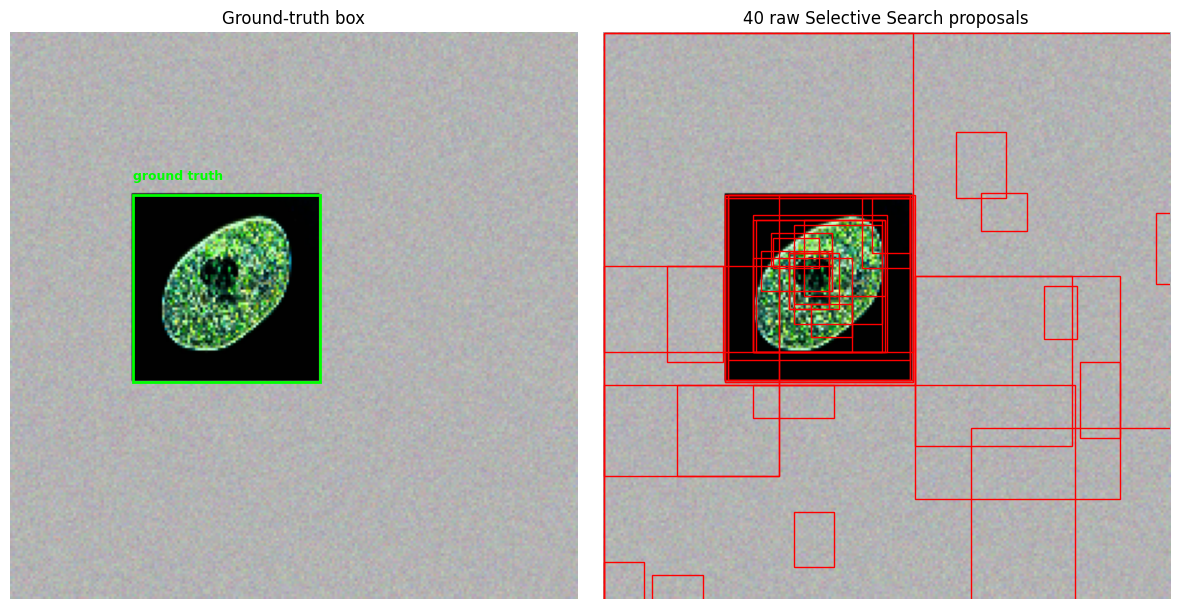

In [11]:
demo_image = train_images[0]
demo_proposals = generate_region_proposals(demo_image, max_proposals=40)

print("Number of proposals found (showing first 40):", len(demo_proposals))

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
show_image_with_box(axes[0], demo_image, train_boxes[0], label_text="ground truth", box_color="lime")
axes[0].set_title("Ground-truth box")

axes[1].imshow(demo_image)
for box in demo_proposals:
    x1, y1, x2, y2 = box
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=1, edgecolor="red", facecolor="none")
    axes[1].add_patch(rect)
axes[1].set_title(f"{len(demo_proposals)} raw Selective Search proposals")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Step 9: Label Proposals and Build the Training Set

Now we do this for real, across the whole training set. For every training image:

1. Generate its Selective Search proposals.
2. Compute each proposal's IoU against that image's true box.
3. Keep proposals with `IoU >= IOU_POSITIVE_THRESHOLD` as **positive** examples (labeled with the
   real class), and proposals with `IoU < IOU_NEGATIVE_THRESHOLD` as **negative** examples (labeled
   `background`) — everything in between gets dropped, as explained in Step 7.
4. Randomly keep only `PROPOSALS_PER_IMAGE_FOR_TRAINING` of them (a mix of positive and negative),
   instead of training on every single proposal from every image — exactly what the original paper
   does too, since the vast majority of proposals are background and training on all of them would
   be slow and heavily imbalanced.
5. Crop and warp each kept proposal to `ROI_SIZE x ROI_SIZE`, ready to feed into a CNN.

This cell does real work across hundreds of images, so it can take a few minutes — a progress message
prints every 100 images.

In [12]:
BACKGROUND_CLASS = num_classes  # one extra class index, reserved for "no object here"


def build_rcnn_training_data(images, boxes, labels, proposals_per_image=PROPOSALS_PER_IMAGE_FOR_TRAINING):
    """Builds a flat training set of warped region crops, out of many images' worth of
    Selective Search proposals. Returns:
      roi_crops       -- (N, ROI_SIZE, ROI_SIZE, 3) warped image crops
      roi_class_labels -- (N,) integer class label for each crop (BACKGROUND_CLASS for background)
      roi_bbox_targets -- (N, 4) bounding-box regression target for each crop (zeros for background)
      roi_is_object    -- (N,) 1 if the crop is a real object (bbox regression applies), else 0
    """
    roi_crops = []
    roi_class_labels = []
    roi_bbox_targets = []
    roi_is_object = []

    for i in range(len(images)):
        image = images[i]
        ground_truth_box = boxes[i]
        true_class = labels[i]

        proposals = generate_region_proposals(image)
        ious = compute_iou_batch(np.array(proposals, dtype=np.float32), ground_truth_box)

        positive_indices = np.where(ious >= IOU_POSITIVE_THRESHOLD)[0]
        negative_indices = np.where(ious < IOU_NEGATIVE_THRESHOLD)[0]

        # Keep a balanced-ish mix: up to half positive, rest negative
        num_positive = min(len(positive_indices), proposals_per_image // 2)
        if num_positive > 0:
            chosen_positive = np.random.choice(positive_indices, size=num_positive, replace=False)
        else:
            chosen_positive = np.array([], dtype=int)

        num_negative = proposals_per_image - num_positive
        num_negative = min(num_negative, len(negative_indices))
        if num_negative > 0:
            chosen_negative = np.random.choice(negative_indices, size=num_negative, replace=False)
        else:
            chosen_negative = np.array([], dtype=int)

        for idx in chosen_positive:
            x1, y1, x2, y2 = [int(v) for v in proposals[idx]]
            crop = cv2.resize(image[y1:y2, x1:x2], (ROI_SIZE, ROI_SIZE))
            roi_crops.append(crop)
            roi_class_labels.append(true_class)
            roi_bbox_targets.append(encode_box_target(proposals[idx], ground_truth_box))
            roi_is_object.append(1)

        for idx in chosen_negative:
            x1, y1, x2, y2 = [int(v) for v in proposals[idx]]
            crop = cv2.resize(image[y1:y2, x1:x2], (ROI_SIZE, ROI_SIZE))
            roi_crops.append(crop)
            roi_class_labels.append(BACKGROUND_CLASS)
            roi_bbox_targets.append(np.zeros(4, dtype=np.float32))
            roi_is_object.append(0)

        if (i + 1) % 100 == 0:
            print(f"  processed {i + 1} / {len(images)} images...")

    return (
        np.array(roi_crops, dtype=np.uint8),
        np.array(roi_class_labels, dtype=np.int32),
        np.array(roi_bbox_targets, dtype=np.float32),
        np.array(roi_is_object, dtype=np.int32),
    )

In [13]:
print("Building R-CNN training data (this runs Selective Search on every training image)...")
rcnn_train_data = build_rcnn_training_data(train_images, train_boxes, train_labels)
rcnn_train_crops, rcnn_train_labels, rcnn_train_bbox_targets, rcnn_train_is_object = rcnn_train_data

print("Building R-CNN validation data...")
rcnn_val_data = build_rcnn_training_data(val_images, val_boxes, val_labels)
rcnn_val_crops, rcnn_val_labels, rcnn_val_bbox_targets, rcnn_val_is_object = rcnn_val_data

print("\nTraining ROI crops:", rcnn_train_crops.shape)
print("Positive (object) ROIs:", rcnn_train_is_object.sum(), "out of", len(rcnn_train_is_object))

Building R-CNN training data (this runs Selective Search on every training image)...
  processed 100 / 631 images...
  processed 200 / 631 images...
  processed 300 / 631 images...
  processed 400 / 631 images...
  processed 500 / 631 images...
  processed 600 / 631 images...
Building R-CNN validation data...
  processed 100 / 158 images...

Training ROI crops: (20192, 64, 64, 3)
Positive (object) ROIs: 9473 out of 20192


## Step 10: Build the R-CNN Model

Two small, separate models, matching how the original paper actually trains R-CNN — as **distinct
stages**, not jointly (Fast R-CNN, in Part B, is where joint training is introduced):

- `rcnn_classifier` — takes one warped `64x64` region crop, predicts which of the 9 classes
  (8 micro-organism types + `background`) it is.
- `rcnn_bbox_regressor` — takes one warped region crop that we already know contains a real object,
  predicts the `(tx, ty, tw, th)` adjustment from Step 6 to better fit the true box. It's only ever
  trained on **positive** crops — there's no sensible "correct box adjustment" for a background crop
  that doesn't contain an object at all.

Both share the same small CNN shape (defined once below, so we're not repeating ourselves) — just
with a different final layer for their different jobs.

In [14]:
def build_small_cnn_backbone(input_shape):
    """A small, simple CNN: three Conv+Pool blocks. This is intentionally much smaller than
    AlexNet/VGG/etc. -- region crops are only 64x64, and we have thousands of them to process
    quickly, so a lightweight backbone keeps this notebook's many training runs fast.
    """
    inputs = Input(shape=input_shape)

    x = Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
    x = MaxPooling2D((2, 2))(x)          # 64x64 -> 32x32

    x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = MaxPooling2D((2, 2))(x)          # 32x32 -> 16x16

    x = Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = MaxPooling2D((2, 2))(x)          # 16x16 -> 8x8

    x = Flatten()(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.3)(x)

    return inputs, x


# --- Classifier model ---
clf_inputs, clf_features = build_small_cnn_backbone((ROI_SIZE, ROI_SIZE, 3))
clf_output = Dense(num_classes + 1, activation="softmax", name="classification")(clf_features)
rcnn_classifier = Model(clf_inputs, clf_output, name="RCNN_Classifier")

# --- Bounding-box regressor model ---
reg_inputs, reg_features = build_small_cnn_backbone((ROI_SIZE, ROI_SIZE, 3))
reg_output = Dense(4, activation="linear", name="bbox_regression")(reg_features)
rcnn_bbox_regressor = Model(reg_inputs, reg_output, name="RCNN_BBox_Regressor")

rcnn_classifier.summary()

Model: "RCNN_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification (Dense)          │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,143,113 (4.36 MB)

 Trainable params: 1,143,113 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

## Step 11: Compile and Train R-CNN

The classifier trains on every crop (object and background alike). The bbox regressor only ever
sees the **positive** crops (`rcnn_train_is_object == 1`) and their `encode_box_target` values — we
filter down to just those before calling `.fit()`.

In [15]:
rcnn_classifier.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_rcnn_classifier = rcnn_classifier.fit(
    rcnn_train_crops, rcnn_train_labels,
    validation_data=(rcnn_val_crops, rcnn_val_labels),
    epochs=10,
    batch_size=32
)

Epoch 1/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.5635 - loss: 2.0307 - val_accuracy: 0.5888 - val_loss: 1.2578
Epoch 2/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6362 - loss: 1.0761 - val_accuracy: 0.6177 - val_loss: 1.2184
Epoch 3/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7026 - loss: 0.8707 - val_accuracy: 0.6203 - val_loss: 1.4651
Epoch 4/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7490 - loss: 0.7370 - val_accuracy: 0.6400 - val_loss: 1.3843
Epoch 5/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7888 - loss: 0.6259 - val_accuracy: 0.6422 - val_loss: 1.5851
Epoch 6/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8105 - loss: 0.5572 - val_accuracy: 0.6341 - val_loss: 1.8029
Epoch 7/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8366 - loss: 0.4867 - val_accuracy: 0.6363 - val_loss: 1.8898
Epoch 8/10
631/631 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8542 - loss: 0.4329 - val_accuracy: 

In [16]:
# Keep only the crops that actually contain an object, for bbox regression training
positive_mask_train = rcnn_train_is_object == 1
positive_mask_val = rcnn_val_is_object == 1

bbox_train_crops = rcnn_train_crops[positive_mask_train]
bbox_train_targets = rcnn_train_bbox_targets[positive_mask_train]
bbox_val_crops = rcnn_val_crops[positive_mask_val]
bbox_val_targets = rcnn_val_bbox_targets[positive_mask_val]

print("Positive crops used for bbox regression training:", len(bbox_train_crops))

rcnn_bbox_regressor.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="mean_squared_error"
)

history_rcnn_bbox = rcnn_bbox_regressor.fit(
    bbox_train_crops, bbox_train_targets,
    validation_data=(bbox_val_crops, bbox_val_targets),
    epochs=10,
    batch_size=32
)

Positive crops used for bbox regression training: 9473
Epoch 1/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 143.8522 - val_loss: 0.0213
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0207 - val_loss: 0.0213
Epoch 3/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0207 - val_loss: 0.0212
Epoch 4/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0206 - val_loss: 0.0212
Epoch 5/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0205 - val_loss: 0.0211
Epoch 6/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0205 - val_loss: 0.0210
Epoch 7/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0204 - val_loss: 0.0210
Epoch 8/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0204 - val_loss: 0.0209
Epoch 9/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0203 - val_loss: 0.0209
Epoch 10/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0203 - val_loss: 0.0208


## Step 12: Run Full R-CNN Inference

This is the complete pipeline described in Step 7, run end-to-end on new images: propose regions,
warp and classify **every single one separately**, keep the confident ones, refine their boxes, and
clean up overlapping detections with NMS. We also time it — this number matters a lot once Part B
shows a faster alternative.

In [17]:
def run_rcnn_detection(image, confidence_threshold=0.9, nms_threshold=0.3):
    """Runs the full R-CNN pipeline on one image and returns the final, cleaned-up detections
    as a list of (box, class_index, confidence).
    """
    proposals = generate_region_proposals(image)

    # Warp every single proposal to ROI_SIZE x ROI_SIZE -- this whole batch is what gets run
    # through the CNN "separately" (Step 7, idea #2)
    warped_crops = []
    for (x1, y1, x2, y2) in proposals:
        crop = cv2.resize(image[y1:y2, x1:x2], (ROI_SIZE, ROI_SIZE))
        warped_crops.append(crop)
    warped_crops = np.array(warped_crops, dtype=np.uint8)

    class_probabilities = rcnn_classifier.predict(warped_crops, verbose=0)
    predicted_classes = np.argmax(class_probabilities, axis=1)
    confidences = np.max(class_probabilities, axis=1)

    # Keep only confident, non-background predictions
    keep_mask = (predicted_classes != BACKGROUND_CLASS) & (confidences >= confidence_threshold)
    kept_indices = np.where(keep_mask)[0]

    if len(kept_indices) == 0:
        return []

    kept_crops = warped_crops[kept_indices]
    kept_proposals = [proposals[i] for i in kept_indices]
    kept_classes = predicted_classes[kept_indices]
    kept_confidences = confidences[kept_indices]

    # Refine each kept box with the bbox regressor
    predicted_deltas = rcnn_bbox_regressor.predict(kept_crops, verbose=0)
    refined_boxes = [
        decode_box_prediction(kept_proposals[i], predicted_deltas[i])
        for i in range(len(kept_proposals))
    ]

    # Clean up overlapping detections
    keep_after_nms = non_max_suppression(refined_boxes, kept_confidences, iou_threshold=nms_threshold)

    detections = [
        (refined_boxes[i], kept_classes[i], kept_confidences[i])
        for i in keep_after_nms
    ]
    return detections

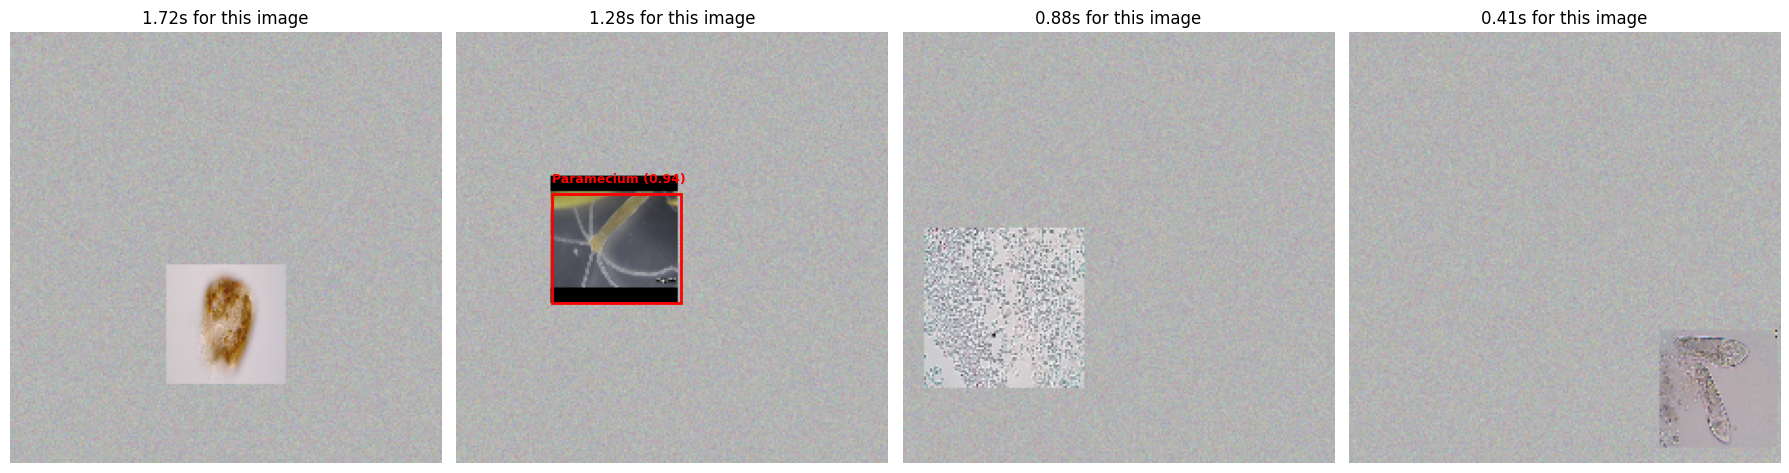

Average R-CNN inference time per image: 1.07 seconds


In [18]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
test_indices = random.sample(range(len(val_images)), 4)

rcnn_timings = []

for ax, idx in zip(axes, test_indices):
    image = val_images[idx]

    start_time = time.time()
    detections = run_rcnn_detection(image)
    elapsed = time.time() - start_time
    rcnn_timings.append(elapsed)

    ax.imshow(image)
    for box, class_idx, confidence in detections:
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
        label = f"{class_names[class_idx]} ({confidence:.2f})"
        ax.text(x1, max(y1 - 6, 0), label, color="red", fontsize=9, weight="bold")
    ax.set_title(f"{elapsed:.2f}s for this image")
    ax.axis("off")

plt.tight_layout()
plt.show()

print(f"Average R-CNN inference time per image: {np.mean(rcnn_timings):.2f} seconds")

## Step 13: Evaluate R-CNN

Real-world object detection papers report a metric called **mAP** (mean Average Precision), which
weighs together detection confidence, localization accuracy, and class correctness across every
possible confidence threshold — genuinely useful, but a fair bit of extra machinery to build well.
For a clear, beginner-readable signal instead, we use a simpler **detection accuracy**: for each
validation image, count it as "found correctly" if at least one kept detection has both the right
class **and** at least `IOU_POSITIVE_THRESHOLD` overlap with the true box.

In [19]:
def evaluate_detector(detect_function, images, boxes, labels, confidence_threshold=0.9):
    correct = 0
    for i in range(len(images)):
        detections = detect_function(images[i], confidence_threshold=confidence_threshold)
        found = False
        for box, class_idx, confidence in detections:
            if class_idx == labels[i] and compute_iou(box, boxes[i]) >= IOU_POSITIVE_THRESHOLD:
                found = True
                break
        if found:
            correct += 1
    return correct / len(images)


rcnn_accuracy = evaluate_detector(run_rcnn_detection, val_images, val_boxes, val_labels)
print(f"R-CNN detection accuracy: {rcnn_accuracy:.4f} ({rcnn_accuracy * 100:.2f}%)")

R-CNN detection accuracy: 0.3038 (30.38%)


---
# Part B: Fast R-CNN (2015)
---

## Step 14: Theory — Inside Fast R-CNN

Fast R-CNN (Girshick, 2015) keeps R-CNN's overall shape — still propose regions, still classify and
refine each one — but fixes exactly the bottleneck Step 7 flagged:

1. **Run the CNN once per image, not once per region.** Instead of warping and re-running the CNN on
   every single one of ~2,000 regions, Fast R-CNN runs the CNN **one single time** on the *whole*
   image, producing one shared feature map. All ~2,000 regions then reuse slices of that *same*
   feature map — the expensive part (the CNN) happens once; only a cheap lookup happens per region.

2. **ROI Pooling: turning a region of the feature map into a fixed-size feature.** A region proposal
   still comes out a different size every time, but the classifier's Dense layers still need a fixed
   input size. ROI Pooling solves this directly on the shared feature map: given a region's box
   coordinates, it crops out that part of the feature map and resizes it down to one fixed size
   (`7x7` here) — Step 15 implements this.

3. **One joint, multi-task loss — trained together, not in separate stages.** R-CNN trained its CNN
   fine-tuning, its SVM classifiers, and its bbox regressor as three *separate* stages (Step 10–11
   mirror that). Fast R-CNN's other big contribution: train **one single network**, with **two
   output heads sharing the same features**, optimized together with one combined loss
   (classification loss + bounding-box loss). Step 18 does exactly that.

**Everything about labeling proposals (IoU thresholds, positive vs. background) is identical to
Part A** — Fast R-CNN doesn't change *what* counts as a good region, only *how efficiently* each
region gets turned into a prediction.

## Step 15: Implement the ROI Pooling Layer

A custom Keras layer. It takes two inputs — a shared feature map (one per image) and a batch of ROI
boxes (several per image, in original-image pixel coordinates) — and returns one fixed-size
(`7x7xchannels`) pooled feature per box.

Under the hood, `tf.image.crop_and_resize` does the actual crop-and-resize work (it needs box
coordinates normalized to `[0, 1]`, which is why we divide by `image_size` first). This is the
standard, modern way to implement ROI Pooling in TensorFlow.

In [20]:
class ROIPoolingLayer(Layer):
    """Pools a fixed-size feature for every ROI box out of one shared feature map."""

    def __init__(self, pooled_size, image_size, **kwargs):
        super().__init__(**kwargs)
        self.pooled_size = pooled_size
        self.image_size = float(image_size)

    def call(self, inputs):
        feature_map, roi_boxes = inputs
        # feature_map: (batch, H, W, channels)
        # roi_boxes:   (batch, num_rois, 4) -- [x1, y1, x2, y2] in ORIGINAL IMAGE pixel coordinates

        batch_size = tf.shape(feature_map)[0]
        num_rois = tf.shape(roi_boxes)[1]

        # crop_and_resize wants normalized [0, 1] coordinates, ordered [y1, x1, y2, x2]
        x1 = roi_boxes[:, :, 0] / self.image_size
        y1 = roi_boxes[:, :, 1] / self.image_size
        x2 = roi_boxes[:, :, 2] / self.image_size
        y2 = roi_boxes[:, :, 3] / self.image_size
        normalized_boxes = tf.stack([y1, x1, y2, x2], axis=-1)
        flat_boxes = tf.reshape(normalized_boxes, [-1, 4])

        # Tells crop_and_resize which image (within the batch) each box belongs to
        box_indices = tf.repeat(tf.range(batch_size), num_rois)

        pooled = tf.image.crop_and_resize(
            feature_map, flat_boxes, box_indices,
            crop_size=(self.pooled_size, self.pooled_size)
        )

        channels = feature_map.shape[-1]
        pooled = tf.reshape(
            pooled, [batch_size, num_rois, self.pooled_size, self.pooled_size, channels]
        )
        return pooled

## Step 16: Prepare Training Data for Fast R-CNN

Same Selective Search proposals and same IoU-based labeling as Part A — what's different here is
*how* the data gets packaged. Each training example is now **one whole image** plus **exactly**
`PROPOSALS_PER_IMAGE_FOR_TRAINING` ROI boxes for that image (with their labels and bbox targets),
all bundled together, since the ROI Pooling layer needs the whole image and its ROIs at the same
time. If an image doesn't naturally have enough positive or negative proposals to fill that count,
we sample a few of them again (with replacement) just to keep every training example the same shape
— a small, clearly-flagged bookkeeping simplification, not a change to any core idea.

In [21]:
def build_fast_rcnn_training_data(images, boxes, labels, num_rois=PROPOSALS_PER_IMAGE_FOR_TRAINING):
    """Returns, for a whole set of images:
      roi_boxes_per_image   -- (N, num_rois, 4)
      roi_labels_per_image  -- (N, num_rois)
      roi_targets_per_image -- (N, num_rois, 4)
      roi_is_object         -- (N, num_rois)  -- used as the bbox loss's sample weight
    alongside the original (unchanged) whole images themselves.
    """
    all_roi_boxes = []
    all_roi_labels = []
    all_roi_targets = []
    all_roi_is_object = []

    for i in range(len(images)):
        image = images[i]
        ground_truth_box = boxes[i]
        true_class = labels[i]

        proposals = np.array(generate_region_proposals(image), dtype=np.float32)
        ious = compute_iou_batch(proposals, ground_truth_box)

        positive_indices = np.where(ious >= IOU_POSITIVE_THRESHOLD)[0]
        negative_indices = np.where(ious < IOU_NEGATIVE_THRESHOLD)[0]

        num_positive = min(len(positive_indices), num_rois // 2)
        num_negative = num_rois - num_positive

        # Sample with replacement if there aren't quite enough of either kind available
        replace_pos = len(positive_indices) < num_positive
        replace_neg = len(negative_indices) < num_negative

        if num_positive > 0 and len(positive_indices) > 0:
            chosen_positive = np.random.choice(positive_indices, size=num_positive, replace=replace_pos)
        else:
            chosen_positive = np.array([], dtype=int)

        if len(negative_indices) > 0:
            chosen_negative = np.random.choice(negative_indices, size=num_negative, replace=replace_neg)
        else:
            # extremely unlikely, but fall back to re-using positive indices rather than crash
            chosen_negative = np.random.choice(positive_indices, size=num_negative, replace=True)

        chosen_indices = np.concatenate([chosen_positive, chosen_negative])

        image_roi_boxes = proposals[chosen_indices]
        image_roi_labels = []
        image_roi_targets = []
        image_roi_is_object = []

        for idx in chosen_indices:
            if ious[idx] >= IOU_POSITIVE_THRESHOLD:
                image_roi_labels.append(true_class)
                image_roi_targets.append(encode_box_target(proposals[idx], ground_truth_box))
                image_roi_is_object.append(1.0)
            else:
                image_roi_labels.append(BACKGROUND_CLASS)
                image_roi_targets.append(np.zeros(4, dtype=np.float32))
                image_roi_is_object.append(0.0)

        all_roi_boxes.append(image_roi_boxes)
        all_roi_labels.append(image_roi_labels)
        all_roi_targets.append(image_roi_targets)
        all_roi_is_object.append(image_roi_is_object)

        if (i + 1) % 100 == 0:
            print(f"  processed {i + 1} / {len(images)} images...")

    return (
        np.array(all_roi_boxes, dtype=np.float32),
        np.array(all_roi_labels, dtype=np.int32),
        np.array(all_roi_targets, dtype=np.float32),
        np.array(all_roi_is_object, dtype=np.float32),
    )

In [22]:
print("Building Fast R-CNN training data...")
frcnn_train_data = build_fast_rcnn_training_data(train_images, train_boxes, train_labels)
frcnn_train_roi_boxes, frcnn_train_roi_labels, frcnn_train_roi_targets, frcnn_train_roi_is_object = frcnn_train_data

print("Building Fast R-CNN validation data...")
frcnn_val_data = build_fast_rcnn_training_data(val_images, val_boxes, val_labels)
frcnn_val_roi_boxes, frcnn_val_roi_labels, frcnn_val_roi_targets, frcnn_val_roi_is_object = frcnn_val_data

print("\nroi_boxes shape:", frcnn_train_roi_boxes.shape)

Building Fast R-CNN training data...
  processed 100 / 631 images...
  processed 200 / 631 images...
  processed 300 / 631 images...
  processed 400 / 631 images...
  processed 500 / 631 images...
  processed 600 / 631 images...
Building Fast R-CNN validation data...
  processed 100 / 158 images...

roi_boxes shape: (631, 32, 4)


## Step 17: Build the Fast R-CNN Model

One model, two inputs, two outputs:

- **Inputs:** the whole image, and that image's `PROPOSALS_PER_IMAGE_FOR_TRAINING` ROI boxes.
- A small CNN backbone (same shape as Part A's, for a fair comparison) runs on the whole image
  **once**, producing one shared feature map.
- `ROIPoolingLayer` pulls a fixed-size feature out of that shared map for every ROI box.
- A shared `Dense` head (wrapped in `TimeDistributed`, so the *same* weights are applied to every ROI
  independently) processes each pooled feature.
- Two small output heads, same job as Part A's two separate models: `classification` and
  `bbox_regression` — except here they share one backbone and train together.

In [23]:
IMAGE_INPUT_SIZE = CANVAS_SIZE  # the whole 224x224 scene, not a cropped region

image_input = Input(shape=(IMAGE_INPUT_SIZE, IMAGE_INPUT_SIZE, 3), name="image_input")
roi_input = Input(shape=(None, 4), name="roi_input")  # None = accepts any number of ROIs, so the same model can be fed either the fixed-size training batches or a differently-sized set of real proposals at inference time

# Same backbone shape as Part A's build_small_cnn_backbone, but now it only runs ONCE per image
x = Conv2D(32, (3, 3), activation="relu", padding="same")(image_input)
x = MaxPooling2D((2, 2))(x)          # 224 -> 112
x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
x = MaxPooling2D((2, 2))(x)          # 112 -> 56
x = Conv2D(128, (3, 3), activation="relu", padding="same")(x)
shared_feature_map = MaxPooling2D((2, 2))(x)   # 56 -> 28 -- this is now a SHARED feature map

pooled_rois = ROIPoolingLayer(pooled_size=7, image_size=IMAGE_INPUT_SIZE)([shared_feature_map, roi_input])

flattened = tf.keras.layers.TimeDistributed(Flatten())(pooled_rois)
shared_head = tf.keras.layers.TimeDistributed(Dense(128, activation="relu"))(flattened)
shared_head = tf.keras.layers.TimeDistributed(Dropout(0.3))(shared_head)

classification_output = tf.keras.layers.TimeDistributed(
    Dense(num_classes + 1, activation="softmax"), name="classification"
)(shared_head)
bbox_output = tf.keras.layers.TimeDistributed(
    Dense(4, activation="linear"), name="bbox_regression"
)(shared_head)

fast_rcnn_model = Model([image_input, roi_input], [classification_output, bbox_output], name="FastRCNN")
fast_rcnn_model.summary()

Model: "FastRCNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 224, 224,  │        896 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 112, 112,  │          0 │ conv2d_6[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d_6[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 56, 56,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 56, 56,    │     73,856 │ max_pooling2d_7[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 28, 28,    │          0 │ conv2d_8[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ roi_input           │ (None, None, 4)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ roi_pooling_layer   │ (None, None, 7,   │          0 │ max_pooling2d_8[… │
│ (ROIPoolingLayer)   │ 7, 128)           │            │ roi_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, None,      │          0 │ roi_pooling_laye… │
│ (TimeDistributed)   │ 6272)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, None, 128) │    802,944 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_2  │ (None, None, 128) │          0 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification      │ (None, None, 9)   │      1,161 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bbox_regression     │ (None, None, 4)   │        516 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 897,869 (3.43 MB)

 Trainable params: 897,869 (3.43 MB)

 Non-trainable params: 0 (0.00 B)

## Step 18: Compile and Train Fast R-CNN

Both heads train **together** this time, with one combined loss — the real difference from Part A's
two separate `.fit()` calls. The only slightly unusual part: `sample_weight` for the bbox-regression
output is set to `roi_is_object` (1 for a real object, 0 for background), so background ROIs
contribute **zero** to the bounding-box loss — there's no sensible box to refine for a region with no
object in it, exactly as in Part A, just expressed differently since both heads now train in the same
`.fit()` call.

In [24]:
fast_rcnn_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss={
        "classification": "sparse_categorical_crossentropy",
        "bbox_regression": "mean_squared_error"
    },
    metrics={"classification": "accuracy"},
    jit_compile=False  # Disabled to prevent XLA compiler errors with CropAndResize
)

history_fast_rcnn = fast_rcnn_model.fit(
    x=[train_images, frcnn_train_roi_boxes],
    y=[frcnn_train_roi_labels, frcnn_train_roi_targets],
    sample_weight=[
        np.ones_like(frcnn_train_roi_is_object),  # every ROI counts fully for classification
        frcnn_train_roi_is_object                 # only object ROIs count for bbox regression
    ],
    validation_data=(
        [val_images, frcnn_val_roi_boxes],
        [frcnn_val_roi_labels, frcnn_val_roi_targets],
        [np.ones_like(frcnn_val_roi_is_object), frcnn_val_roi_is_object]
    ),
    epochs=10,
    batch_size=8
)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 75ms/step - bbox_regression_loss: 124.4613 - classification_accuracy: 0.4155 - classification_loss: 2.2194 - loss: 126.8790 - val_bbox_regression_loss: 0.0334 - val_classification_accuracy: 0.5372 - val_classification_loss: 1.4709 - val_loss: 1.5041
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - bbox_regression_loss: 0.0383 - classification_accuracy: 0.5353 - classification_loss: 1.4353 - loss: 1.4739 - val_bbox_regression_loss: 0.0158 - val_classification_accuracy: 0.5607 - val_classification_loss: 1.3336 - val_loss: 1.3487
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - bbox_regression_loss: 0.0253 - classification_accuracy: 0.5542 - classification_loss: 1.3385 - loss: 1.3643 - val_bbox_regression_loss: 0.0141 - val_classification_accuracy: 0.5578 - val_classification_loss: 1.2571 - val_loss: 1.2706
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - bbox_regression_loss: 0.0164 - classification_accuracy: 0.5627 - classification_l

## Step 19: Run Full Fast R-CNN Inference

Same overall pipeline shape as Part A's `run_rcnn_detection` — propose, classify, refine, clean up
with NMS — but now the CNN only runs **once** per image, with ROI Pooling doing the rest. Timed the
same way, for a direct comparison with Part A.

In [25]:
def run_fast_rcnn_detection(image, confidence_threshold=0.9, nms_threshold=0.3):
    """Runs the full Fast R-CNN pipeline on one image."""
    proposals = generate_region_proposals(image)
    if len(proposals) == 0:
        return []

    image_batch = np.expand_dims(image, axis=0)
    roi_batch = np.expand_dims(np.array(proposals, dtype=np.float32), axis=0)

    class_probabilities, predicted_deltas = fast_rcnn_model.predict([image_batch, roi_batch], verbose=0)
    class_probabilities = class_probabilities[0]   # drop the batch dimension (batch size 1)
    predicted_deltas = predicted_deltas[0]

    predicted_classes = np.argmax(class_probabilities, axis=1)
    confidences = np.max(class_probabilities, axis=1)

    keep_mask = (predicted_classes != BACKGROUND_CLASS) & (confidences >= confidence_threshold)
    kept_indices = np.where(keep_mask)[0]
    if len(kept_indices) == 0:
        return []

    refined_boxes = [
        decode_box_prediction(proposals[i], predicted_deltas[i])
        for i in kept_indices
    ]
    kept_classes = predicted_classes[kept_indices]
    kept_confidences = confidences[kept_indices]

    keep_after_nms = non_max_suppression(refined_boxes, kept_confidences, iou_threshold=nms_threshold)
    detections = [(refined_boxes[i], kept_classes[i], kept_confidences[i]) for i in keep_after_nms]
    return detections

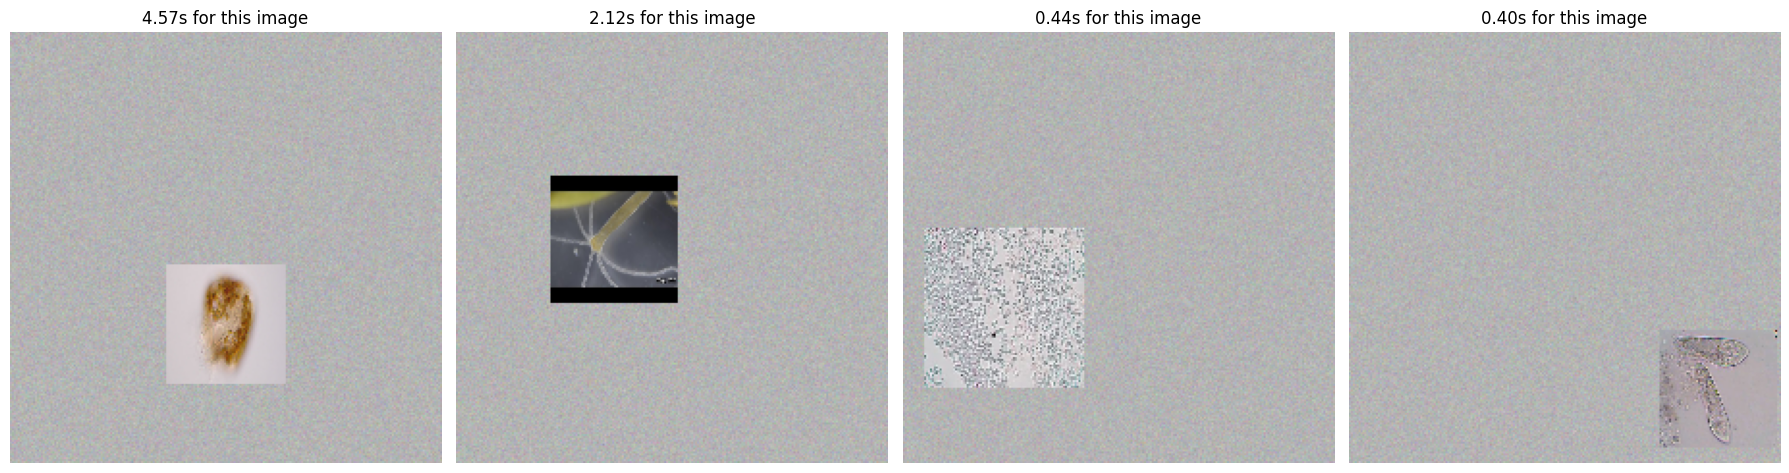

Average Fast R-CNN inference time per image: 1.88 seconds
Average R-CNN inference time per image:      1.07 seconds


In [26]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fast_rcnn_timings = []

for ax, idx in zip(axes, test_indices):   # same test_indices as Part A, for a fair comparison
    image = val_images[idx]

    start_time = time.time()
    detections = run_fast_rcnn_detection(image)
    elapsed = time.time() - start_time
    fast_rcnn_timings.append(elapsed)

    ax.imshow(image)
    for box, class_idx, confidence in detections:
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor="blue", facecolor="none")
        ax.add_patch(rect)
        label = f"{class_names[class_idx]} ({confidence:.2f})"
        ax.text(x1, max(y1 - 6, 0), label, color="blue", fontsize=9, weight="bold")
    ax.set_title(f"{elapsed:.2f}s for this image")
    ax.axis("off")

plt.tight_layout()
plt.show()

print(f"Average Fast R-CNN inference time per image: {np.mean(fast_rcnn_timings):.2f} seconds")
print(f"Average R-CNN inference time per image:      {np.mean(rcnn_timings):.2f} seconds")

## Step 20: Evaluate Fast R-CNN

In [27]:
fast_rcnn_accuracy = evaluate_detector(run_fast_rcnn_detection, val_images, val_boxes, val_labels)
print(f"Fast R-CNN detection accuracy: {fast_rcnn_accuracy:.4f} ({fast_rcnn_accuracy * 100:.2f}%)")
print(f"R-CNN detection accuracy:      {rcnn_accuracy:.4f} ({rcnn_accuracy * 100:.2f}%)")

Fast R-CNN detection accuracy: 0.0000 (0.00%)
R-CNN detection accuracy:      0.3038 (30.38%)


---
# Part C: Faster R-CNN (2015)
---

## Step 21: Theory — Inside Faster R-CNN

Fast R-CNN (Part B) fixed the "CNN runs once vs. 2,000 times" problem, but it still leans on
Selective Search for its region proposals — a classical, CPU-bound, **non-learned** algorithm that
turns out to be the new bottleneck once everything else got fast. Faster R-CNN (Ren, He, Girshick &
Sun, 2015) replaces it with something genuinely new: a small neural network that **learns to propose
regions itself**.

1. **Anchors: a fixed grid of "guess boxes."** Instead of Selective Search's data-dependent regions,
   Faster R-CNN lays down a fixed grid of candidate boxes called **anchors**, at every location on
   the shared feature map — multiple anchors per location, at different **scales** (small / medium /
   large) and **aspect ratios** (wide / square / tall), so that *something* in the grid is likely to
   roughly match any real object's size and shape. With a `28x28` feature map and 9 anchors per
   location (3 scales x 3 ratios, the original paper's own setup), that's `28 x 28 x 9 = 7,056`
   anchor boxes — covering the image fully and densely, computed once, with no image content needed
   to define them (Step 22).

2. **The Region Proposal Network (RPN): a tiny classifier riding on the shared feature map.** A
   `3x3` convolution slides across the feature map, feeding two small sibling `1x1` convolutions: one
   predicts an **objectness score** for every anchor at that location ("does this anchor contain
   *any* object, regardless of class?" — not yet "which micro-organism type," just "something vs.
   nothing"), the other predicts the same `(tx, ty, tw, th)` box adjustment from Step 6, this time
   adjusting an *anchor* toward the nearest real object instead of adjusting a Selective Search
   region. Both heads are plain convolutions, so the *same* RPN runs over every location on the
   feature map at once — this really is a small, genuinely learned proposal network (Step 24).

3. **Labeling anchors for training, the same IoU logic as before, with one addition.** Anchors with
   `IoU >= 0.7` against the true box are positive; anchors with `IoU < 0.3` are negative (note the
   stricter 0.7 here vs. Parts A/B's 0.5 — anchors are a denser, cruder starting point than Selective
   Search regions, so the bar for "this one's basically the object already" is set higher); anchors
   in between are ignored, exactly as before. **One addition**: anchors that extend outside the image
   boundary are also ignored during training, since they'd otherwise contribute a very easy "it's not
   an object" signal that teaches the network nothing useful (Step 23).

4. **From anchors + RPN predictions to actual proposals.** At inference (and after training), we take
   every anchor, adjust it using the RPN's predicted deltas, sort by predicted objectness, and run
   Non-Maximum Suppression — producing a clean, small set of *learned* region proposals, playing
   exactly the role Selective Search played in Parts A and B, just without ever calling OpenCV
   (Step 26).

5. **The second stage is identical to Fast R-CNN.** Once we have proposals — learned or not — Faster
   R-CNN hands them to the *exact same* ROI Pooling + shared classification/bbox head from Part B.
   The only thing that changed between Fast R-CNN and Faster R-CNN is **where the proposals come
   from** (Step 27 reuses Part B's architecture, trained fresh on the RPN's own proposals).

## Step 22: Generate Anchors

A fixed grid of candidate boxes, computed once and reused for every image (anchors don't depend on
image content at all — only on the feature map's size).

Total anchors: 7056


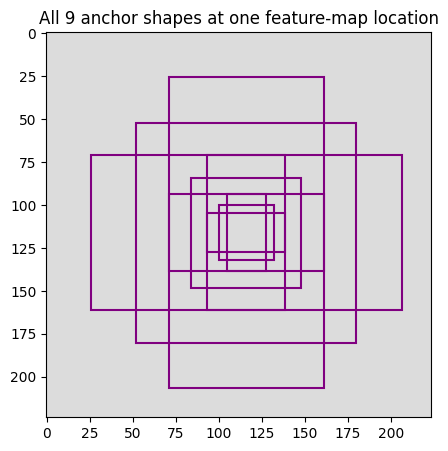

In [28]:
FEATURE_MAP_SIZE = 28          # our backbone shrinks 224x224 down to a 28x28 feature map
FEATURE_STRIDE = CANVAS_SIZE / FEATURE_MAP_SIZE   # = 8: one feature-map cell covers 8x8 image pixels
ANCHOR_SCALES = [32, 64, 128]      # small / medium / large anchor sizes, in pixels
ANCHOR_RATIOS = [0.5, 1.0, 2.0]    # wide / square / tall
NUM_ANCHORS_PER_LOCATION = len(ANCHOR_SCALES) * len(ANCHOR_RATIOS)   # 9
TOTAL_ANCHORS = FEATURE_MAP_SIZE * FEATURE_MAP_SIZE * NUM_ANCHORS_PER_LOCATION   # 7,056


def generate_anchors():
    anchors = []
    for row in range(FEATURE_MAP_SIZE):
        for col in range(FEATURE_MAP_SIZE):
            # Center of this feature-map cell, projected back into image pixel coordinates
            center_x = (col + 0.5) * FEATURE_STRIDE
            center_y = (row + 0.5) * FEATURE_STRIDE
            for scale in ANCHOR_SCALES:
                for ratio in ANCHOR_RATIOS:
                    width = scale * np.sqrt(ratio)
                    height = scale / np.sqrt(ratio)
                    anchors.append([
                        center_x - width / 2, center_y - height / 2,
                        center_x + width / 2, center_y + height / 2
                    ])
    return np.array(anchors, dtype=np.float32)


all_anchors = generate_anchors()
print("Total anchors:", len(all_anchors))

# Visualize every anchor centered at the very middle of the image, to see the 9 scale/ratio shapes
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(np.full((CANVAS_SIZE, CANVAS_SIZE, 3), 220, dtype=np.uint8))
middle_row, middle_col = FEATURE_MAP_SIZE // 2, FEATURE_MAP_SIZE // 2
start_index = (middle_row * FEATURE_MAP_SIZE + middle_col) * NUM_ANCHORS_PER_LOCATION
middle_cell_anchors = all_anchors[start_index : start_index + NUM_ANCHORS_PER_LOCATION]
for box in middle_cell_anchors:
    x1, y1, x2, y2 = box
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=1.5, edgecolor="purple", facecolor="none")
    ax.add_patch(rect)
ax.set_title("All 9 anchor shapes at one feature-map location")
plt.show()

## Step 23: Label Anchors for RPN Training

For every training image, compare all 7,056 anchors against that image's true box, and assign each
one a label: `1` (object), `0` (background), or ignored — using the stricter 0.7 / 0.3 thresholds
from Step 21. Anchors crossing the image boundary are ignored too. We always keep at least one
positive anchor per image (the single best-overlapping one), even if nothing quite reaches 0.7 —
otherwise an image could end up with no positive training signal at all.

In [29]:
ANCHOR_IOU_POSITIVE_THRESHOLD = 0.7
ANCHOR_IOU_NEGATIVE_THRESHOLD = 0.3

# Anchors that stay fully inside the image -- computed once, since it never depends on image content
anchors_in_bounds = (
    (all_anchors[:, 0] >= 0) & (all_anchors[:, 1] >= 0) &
    (all_anchors[:, 2] <= CANVAS_SIZE) & (all_anchors[:, 3] <= CANVAS_SIZE)
)
print("In-bounds anchors:", anchors_in_bounds.sum(), "out of", TOTAL_ANCHORS)


def build_rpn_training_labels(boxes):
    """For a whole set of images' ground-truth boxes, returns:
      objectness_labels  -- (N, TOTAL_ANCHORS), 1/0
      objectness_weights -- (N, TOTAL_ANCHORS), 1 to use this anchor, 0 to ignore it
      bbox_targets        -- (N, TOTAL_ANCHORS, 4)
      bbox_weights         -- (N, TOTAL_ANCHORS), 1 only for positive anchors
    """
    all_objectness_labels = []
    all_objectness_weights = []
    all_bbox_targets = []
    all_bbox_weights = []

    for gt_box in boxes:
        ious = compute_iou_batch(all_anchors, gt_box)

        objectness = np.zeros(TOTAL_ANCHORS, dtype=np.float32)
        weights = np.zeros(TOTAL_ANCHORS, dtype=np.float32)

        objectness[ious >= ANCHOR_IOU_POSITIVE_THRESHOLD] = 1.0
        weights[ious >= ANCHOR_IOU_POSITIVE_THRESHOLD] = 1.0
        weights[ious < ANCHOR_IOU_NEGATIVE_THRESHOLD] = 1.0   # negatives also count toward the loss

        weights[~anchors_in_bounds] = 0.0   # ignore out-of-bounds anchors regardless of IoU

        best_anchor = np.argmax(ious)       # guarantee at least one positive anchor
        objectness[best_anchor] = 1.0
        weights[best_anchor] = 1.0

        bbox_targets = np.zeros((TOTAL_ANCHORS, 4), dtype=np.float32)
        bbox_weights = np.zeros(TOTAL_ANCHORS, dtype=np.float32)
        positive_anchor_indices = np.where(objectness == 1.0)[0]
        for idx in positive_anchor_indices:
            bbox_targets[idx] = encode_box_target(all_anchors[idx], gt_box)
            bbox_weights[idx] = 1.0

        all_objectness_labels.append(objectness)
        all_objectness_weights.append(weights)
        all_bbox_targets.append(bbox_targets)
        all_bbox_weights.append(bbox_weights)

    return (
        np.array(all_objectness_labels, dtype=np.float32),
        np.array(all_objectness_weights, dtype=np.float32),
        np.array(all_bbox_targets, dtype=np.float32),
        np.array(all_bbox_weights, dtype=np.float32),
    )


print("Labeling anchors for the training set...")
rpn_train_labels, rpn_train_label_weights, rpn_train_bbox_targets, rpn_train_bbox_weights = \
    build_rpn_training_labels(train_boxes)

print("Labeling anchors for the validation set...")
rpn_val_labels, rpn_val_label_weights, rpn_val_bbox_targets, rpn_val_bbox_weights = \
    build_rpn_training_labels(val_boxes)

print("\nAverage positive anchors per image:", rpn_train_labels.sum(axis=1).mean())

In-bounds anchors: 3160 out of 7056
Labeling anchors for the training set...
Labeling anchors for the validation set...

Average positive anchors per image: 2.2820919


## Step 24: Build the Region Proposal Network (RPN)

Same small CNN backbone shape as Parts A and B (for a fair comparison), then the small RPN "head"
described in Step 21: one shared `3x3` convolution, feeding two sibling `1x1` convolutions —
`objectness` (one score per anchor, per location) and `bbox_regression` (four numbers per anchor, per
location). `Reshape` just flattens the `28x28x9` grid down to a plain `7056`-long list, matching the
flat `all_anchors` array from Step 22.

In [30]:
rpn_image_input = Input(shape=(CANVAS_SIZE, CANVAS_SIZE, 3), name="image_input")

x = Conv2D(32, (3, 3), activation="relu", padding="same")(rpn_image_input)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(128, (3, 3), activation="relu", padding="same")(x)
rpn_feature_map = MaxPooling2D((2, 2))(x)   # 28x28x128, same shape as Part B's shared feature map

rpn_shared = Conv2D(128, (3, 3), activation="relu", padding="same", name="rpn_conv")(rpn_feature_map)

objectness_grid = Conv2D(NUM_ANCHORS_PER_LOCATION, (1, 1), activation="sigmoid")(rpn_shared)
objectness_output = tf.keras.layers.Reshape((TOTAL_ANCHORS, 1), name="objectness")(objectness_grid)  # trailing 1 so per-anchor sample weighting lines up correctly with binary_crossentropy

bbox_grid = Conv2D(NUM_ANCHORS_PER_LOCATION * 4, (1, 1), activation="linear")(rpn_shared)
bbox_output = tf.keras.layers.Reshape((TOTAL_ANCHORS, 4), name="bbox_regression")(bbox_grid)

rpn_model = Model(rpn_image_input, [objectness_output, bbox_output], name="RPN")
rpn_model.summary()

Model: "RPN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 224, 224,  │        896 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 112, 112,  │          0 │ conv2d_9[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 112, 112,  │     18,496 │ max_pooling2d_9[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 56, 56,    │          0 │ conv2d_10[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 56, 56,    │     73,856 │ max_pooling2d_10… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 28, 28,    │          0 │ conv2d_11[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rpn_conv (Conv2D)   │ (None, 28, 28,    │    147,584 │ max_pooling2d_11… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 28, 28, 9) │      1,161 │ rpn_conv[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 28, 28,    │      4,644 │ rpn_conv[0][0]    │
│                     │ 36)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ objectness          │ (None, 7056, 1)   │          0 │ conv2d_12[0][0]   │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bbox_regression     │ (None, 7056, 4)   │          0 │ conv2d_13[0][0]   │
│ (Reshape)           │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 246,637 (963.43 KB)

 Trainable params: 246,637 (963.43 KB)

 Non-trainable params: 0 (0.00 B)

## Step 25: Compile and Train the RPN

Same masked-loss idea as Part B's bbox head, applied to anchors instead of ROIs: `objectness_weights`
zeroes out the ignored anchors (the "in-between" and out-of-bounds ones from Step 23), and
`bbox_weights` keeps the box-regression loss restricted to positive anchors only.

In [31]:
rpn_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss={
        "objectness": "binary_crossentropy",
        "bbox_regression": "mean_squared_error"
    },
    metrics={"objectness": "accuracy"}
)

# The objectness head outputs shape (batch, TOTAL_ANCHORS, 1) -- see Step 24 -- so its labels
# need that same trailing dimension added
rpn_train_labels_3d = np.expand_dims(rpn_train_labels, axis=-1)
rpn_val_labels_3d = np.expand_dims(rpn_val_labels, axis=-1)

history_rpn = rpn_model.fit(
    x=train_images,
    y=[rpn_train_labels_3d, rpn_train_bbox_targets],
    sample_weight=[rpn_train_label_weights, rpn_train_bbox_weights],
    validation_data=(
        val_images,
        [rpn_val_labels_3d, rpn_val_bbox_targets],
        [rpn_val_label_weights, rpn_val_bbox_weights]
    ),
    epochs=10,
    batch_size=8
)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 96ms/step - bbox_regression_loss: 0.0124 - loss: 0.1296 - objectness_accuracy: 0.9382 - objectness_loss: 0.1169 - val_bbox_regression_loss: 2.9551e-04 - val_loss: 0.0037 - val_objectness_accuracy: 0.9996 - val_objectness_loss: 0.0034
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - bbox_regression_loss: 1.4796e-04 - loss: 0.0029 - objectness_accuracy: 0.9996 - objectness_loss: 0.0027 - val_bbox_regression_loss: 1.4241e-04 - val_loss: 0.0035 - val_objectness_accuracy: 0.9996 - val_objectness_loss: 0.0033
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - bbox_regression_loss: 9.6479e-05 - loss: 0.0026 - objectness_accuracy: 0.9997 - objectness_loss: 0.0025 - val_bbox_regression_loss: 1.1400e-04 - val_loss: 0.0033 - val_objectness_accuracy: 0.9996 - val_objectness_loss: 0.0031
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - bbox_regression_loss: 7.1891e-05 - loss: 0.0025 - objectness_accuracy: 0.9996 - objectness_loss: 0.0024 - val_bbo

## Step 26: Generate Learned Proposals from the Trained RPN

The replacement for Selective Search: run the trained RPN on an image, adjust every anchor by its
predicted box deltas, keep the ones with the highest predicted objectness, and clean up with NMS —
exactly the same "propose regions" job Selective Search did in Parts A and B, just produced by a
small trained network instead of a classical algorithm.

In [32]:
def get_rpn_proposals(image, top_k_by_objectness=300, num_proposals_to_keep=NUM_PROPOSALS_PER_IMAGE, nms_threshold=0.7):
    """Runs the trained RPN on one image and returns its proposed region boxes."""
    image_batch = np.expand_dims(image, axis=0)
    objectness_scores, bbox_deltas = rpn_model.predict(image_batch, verbose=0)
    objectness_scores = objectness_scores[0].reshape(-1)   # (TOTAL_ANCHORS, 1) -> flat (TOTAL_ANCHORS,)
    bbox_deltas = bbox_deltas[0]               # (TOTAL_ANCHORS, 4)

    # Only decode and consider the anchors the RPN is most confident about -- much faster than
    # decoding and NMS-ing all 7,056 of them, and the low-confidence ones would get filtered out
    # by NMS anyway
    top_indices = np.argsort(objectness_scores)[::-1][:top_k_by_objectness]

    decoded_boxes = []
    for idx in top_indices:
        box = decode_box_prediction(all_anchors[idx], bbox_deltas[idx])
        # Clip to stay inside the image, in case a predicted adjustment pushed it outside
        box = np.clip(box, 0, CANVAS_SIZE)
        decoded_boxes.append(box)

    top_scores = objectness_scores[top_indices]
    keep_indices = non_max_suppression(decoded_boxes, top_scores, iou_threshold=nms_threshold)
    keep_indices = keep_indices[:num_proposals_to_keep]

    return [decoded_boxes[i] for i in keep_indices]

Number of RPN-generated proposals: 200


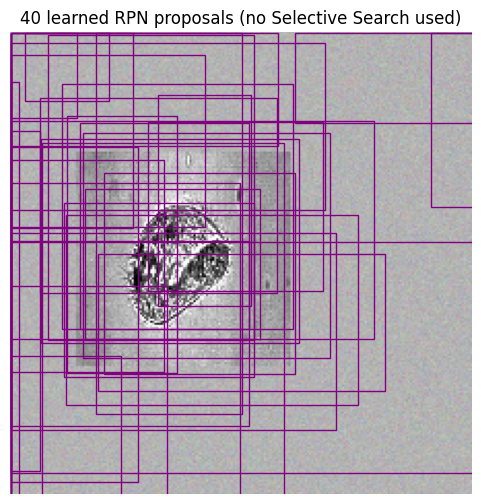

In [33]:
demo_rpn_proposals = get_rpn_proposals(val_images[0])
print("Number of RPN-generated proposals:", len(demo_rpn_proposals))

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(val_images[0])
for box in demo_rpn_proposals[:40]:
    x1, y1, x2, y2 = box
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=1, edgecolor="purple", facecolor="none")
    ax.add_patch(rect)
ax.set_title(f"{min(40, len(demo_rpn_proposals))} learned RPN proposals (no Selective Search used)")
ax.axis("off")
plt.show()

## Step 27: Build and Train the Faster R-CNN Detection Head

The second stage is architecturally identical to Part B's Fast R-CNN model — same ROI Pooling layer,
same shared `Dense` head, same two outputs — just fed by the RPN's own proposals (Step 26) instead of
Selective Search.

**One simplification, clearly flagged:** the original paper carefully *shares* one single backbone
between the RPN and this detection head (trained with an alternating or approximate joint-training
procedure — a genuinely advanced training trick). For clarity, this notebook instead gives the
detection head its **own**, separately-trained backbone, and uses the already-trained RPN purely as a
*source of region proposals*. The core idea this whole Part exists to demonstrate — replacing
Selective Search with a learned proposal network — is fully intact; only the backbone-sharing
optimization is simplified away.

In [34]:
print("Generating RPN proposals and labeling them for every training image (this calls the trained RPN on every image)...")

def build_faster_rcnn_training_data(images, boxes, labels, num_rois=PROPOSALS_PER_IMAGE_FOR_TRAINING):
    """Exactly the same idea as Part B's build_fast_rcnn_training_data, except the candidate
    regions now come from get_rpn_proposals() instead of Selective Search.
    """
    all_roi_boxes, all_roi_labels, all_roi_targets, all_roi_is_object = [], [], [], []

    for i in range(len(images)):
        image = images[i]
        ground_truth_box = boxes[i]
        true_class = labels[i]

        proposals = np.array(get_rpn_proposals(image), dtype=np.float32)
        if len(proposals) == 0:
            continue
        ious = compute_iou_batch(proposals, ground_truth_box)

        positive_indices = np.where(ious >= IOU_POSITIVE_THRESHOLD)[0]
        negative_indices = np.where(ious < IOU_NEGATIVE_THRESHOLD)[0]

        num_positive = min(len(positive_indices), num_rois // 2)
        num_negative = num_rois - num_positive

        if num_positive > 0:
            chosen_positive = np.random.choice(positive_indices, size=num_positive, replace=len(positive_indices) < num_positive)
        else:
            chosen_positive = np.array([], dtype=int)

        if len(negative_indices) > 0:
            chosen_negative = np.random.choice(negative_indices, size=num_negative, replace=len(negative_indices) < num_negative)
        else:
            chosen_negative = np.random.choice(np.arange(len(proposals)), size=num_negative, replace=True)

        chosen_indices = np.concatenate([chosen_positive, chosen_negative])

        image_roi_boxes, image_roi_labels, image_roi_targets, image_roi_is_object = [], [], [], []
        for idx in chosen_indices:
            image_roi_boxes.append(proposals[idx])
            if ious[idx] >= IOU_POSITIVE_THRESHOLD:
                image_roi_labels.append(true_class)
                image_roi_targets.append(encode_box_target(proposals[idx], ground_truth_box))
                image_roi_is_object.append(1.0)
            else:
                image_roi_labels.append(BACKGROUND_CLASS)
                image_roi_targets.append(np.zeros(4, dtype=np.float32))
                image_roi_is_object.append(0.0)

        all_roi_boxes.append(image_roi_boxes)
        all_roi_labels.append(image_roi_labels)
        all_roi_targets.append(image_roi_targets)
        all_roi_is_object.append(image_roi_is_object)

        if (i + 1) % 100 == 0:
            print(f"  processed {i + 1} / {len(images)} images...")

    return (
        np.array(all_roi_boxes, dtype=np.float32),
        np.array(all_roi_labels, dtype=np.int32),
        np.array(all_roi_targets, dtype=np.float32),
        np.array(all_roi_is_object, dtype=np.float32),
    )


faster_train_data = build_faster_rcnn_training_data(train_images, train_boxes, train_labels)
faster_train_roi_boxes, faster_train_roi_labels, faster_train_roi_targets, faster_train_roi_is_object = faster_train_data

faster_val_data = build_faster_rcnn_training_data(val_images, val_boxes, val_labels)
faster_val_roi_boxes, faster_val_roi_labels, faster_val_roi_targets, faster_val_roi_is_object = faster_val_data

Generating RPN proposals and labeling them for every training image (this calls the trained RPN on every image)...
  processed 100 / 631 images...
  processed 200 / 631 images...
  processed 300 / 631 images...
  processed 400 / 631 images...
  processed 500 / 631 images...
  processed 600 / 631 images...
  processed 100 / 158 images...


In [35]:
# Same architecture shape as Part B's Fast R-CNN model, with its own freshly-initialized backbone
det_image_input = Input(shape=(CANVAS_SIZE, CANVAS_SIZE, 3), name="image_input")
det_roi_input = Input(shape=(None, 4), name="roi_input")  # None = accepts any number of ROIs, so the same model can be fed either the fixed-size training batches or a differently-sized set of real proposals at inference time

x = Conv2D(32, (3, 3), activation="relu", padding="same")(det_image_input)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(128, (3, 3), activation="relu", padding="same")(x)
det_feature_map = MaxPooling2D((2, 2))(x)

det_pooled = ROIPoolingLayer(pooled_size=7, image_size=CANVAS_SIZE)([det_feature_map, det_roi_input])
det_flat = tf.keras.layers.TimeDistributed(Flatten())(det_pooled)
det_shared = tf.keras.layers.TimeDistributed(Dense(128, activation="relu"))(det_flat)
det_shared = tf.keras.layers.TimeDistributed(Dropout(0.3))(det_shared)

det_classification = tf.keras.layers.TimeDistributed(
    Dense(num_classes + 1, activation="softmax"), name="classification"
)(det_shared)
det_bbox = tf.keras.layers.TimeDistributed(
    Dense(4, activation="linear"), name="bbox_regression"
)(det_shared)

faster_rcnn_detector = Model([det_image_input, det_roi_input], [det_classification, det_bbox], name="FasterRCNN_Detector")

faster_rcnn_detector.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss={"classification": "sparse_categorical_crossentropy", "bbox_regression": "mean_squared_error"},
    metrics={"classification": "accuracy"},
    jit_compile=False  # Disabled to prevent XLA compiler errors with CropAndResize
)

history_faster_rcnn = faster_rcnn_detector.fit(
    x=[train_images, faster_train_roi_boxes],
    y=[faster_train_roi_labels, faster_train_roi_targets],
    sample_weight=[np.ones_like(faster_train_roi_is_object), faster_train_roi_is_object],
    validation_data=(
        [val_images, faster_val_roi_boxes],
        [faster_val_roi_labels, faster_val_roi_targets],
        [np.ones_like(faster_val_roi_is_object), faster_val_roi_is_object]
    ),
    epochs=10,
    batch_size=8
)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - bbox_regression_loss: 120.9478 - classification_accuracy: 0.6954 - classification_loss: 1.7626 - loss: 122.9034 - val_bbox_regression_loss: 0.0127 - val_classification_accuracy: 0.7510 - val_classification_loss: 1.0048 - val_loss: 1.0213
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - bbox_regression_loss: 0.0345 - classification_accuracy: 0.7490 - classification_loss: 0.9067 - loss: 0.9410 - val_bbox_regression_loss: 0.0251 - val_classification_accuracy: 0.7522 - val_classification_loss: 0.8623 - val_loss: 0.8922
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - bbox_regression_loss: 0.0305 - classification_accuracy: 0.7524 - classification_loss: 0.7948 - loss: 0.8257 - val_bbox_regression_loss: 0.0157 - val_classification_accuracy: 0.7551 - val_classification_loss: 0.7446 - val_loss: 0.7631
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - bbox_regression_loss: 0.0198 - classification_accuracy: 0.7555 - classification_l

## Step 28: Run Full Faster R-CNN Inference

Same shape as Part B's pipeline, with one real difference: region proposals come from the trained
RPN (Step 26), not from calling OpenCV's Selective Search at all.

In [36]:
def run_faster_rcnn_detection(image, confidence_threshold=0.9, nms_threshold=0.3):
    """Runs the full Faster R-CNN pipeline (RPN proposals + detection head) on one image."""
    proposals = get_rpn_proposals(image)
    if len(proposals) == 0:
        return []

    image_batch = np.expand_dims(image, axis=0)
    roi_batch = np.expand_dims(np.array(proposals, dtype=np.float32), axis=0)

    class_probabilities, predicted_deltas = faster_rcnn_detector.predict([image_batch, roi_batch], verbose=0)
    class_probabilities = class_probabilities[0]
    predicted_deltas = predicted_deltas[0]

    predicted_classes = np.argmax(class_probabilities, axis=1)
    confidences = np.max(class_probabilities, axis=1)

    keep_mask = (predicted_classes != BACKGROUND_CLASS) & (confidences >= confidence_threshold)
    kept_indices = np.where(keep_mask)[0]
    if len(kept_indices) == 0:
        return []

    refined_boxes = [decode_box_prediction(proposals[i], predicted_deltas[i]) for i in kept_indices]
    kept_classes = predicted_classes[kept_indices]
    kept_confidences = confidences[kept_indices]

    keep_after_nms = non_max_suppression(refined_boxes, kept_confidences, iou_threshold=nms_threshold)
    return [(refined_boxes[i], kept_classes[i], kept_confidences[i]) for i in keep_after_nms]

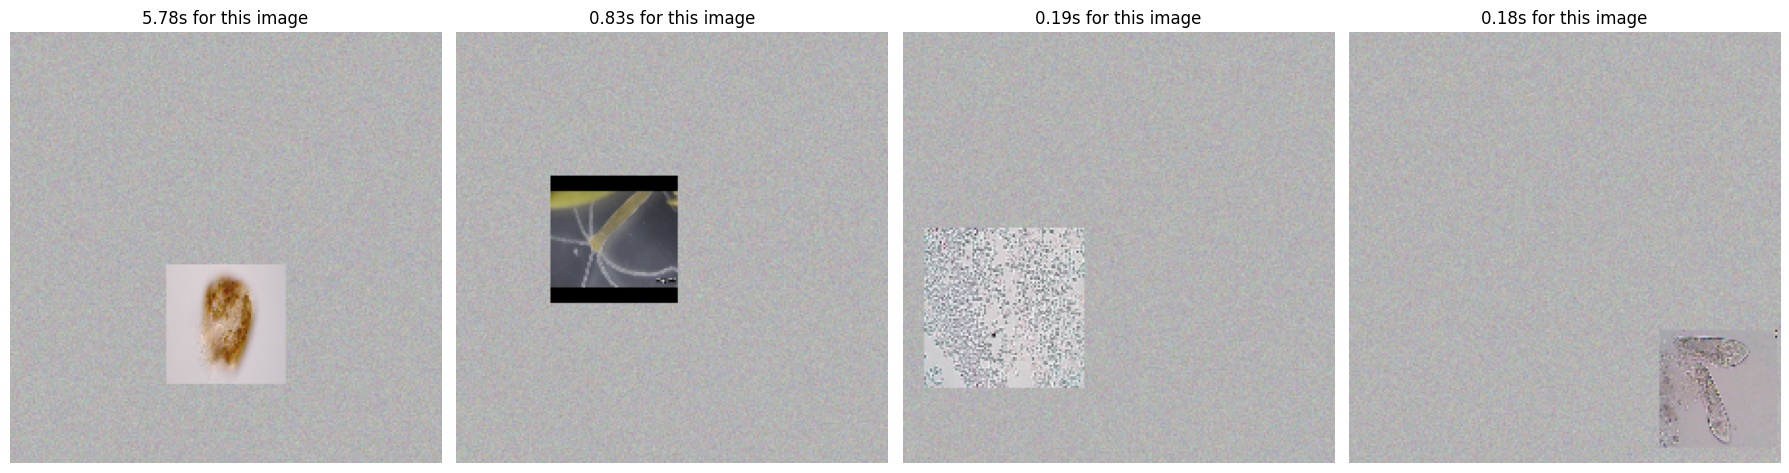

Average Faster R-CNN inference time per image: 1.75 seconds
Average Fast R-CNN inference time per image:    1.88 seconds
Average R-CNN inference time per image:          1.07 seconds


In [37]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
faster_rcnn_timings = []

for ax, idx in zip(axes, test_indices):   # same test_indices as Parts A and B
    image = val_images[idx]

    start_time = time.time()
    detections = run_faster_rcnn_detection(image)
    elapsed = time.time() - start_time
    faster_rcnn_timings.append(elapsed)

    ax.imshow(image)
    for box, class_idx, confidence in detections:
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor="purple", facecolor="none")
        ax.add_patch(rect)
        label = f"{class_names[class_idx]} ({confidence:.2f})"
        ax.text(x1, max(y1 - 6, 0), label, color="purple", fontsize=9, weight="bold")
    ax.set_title(f"{elapsed:.2f}s for this image")
    ax.axis("off")

plt.tight_layout()
plt.show()

print(f"Average Faster R-CNN inference time per image: {np.mean(faster_rcnn_timings):.2f} seconds")
print(f"Average Fast R-CNN inference time per image:    {np.mean(fast_rcnn_timings):.2f} seconds")
print(f"Average R-CNN inference time per image:          {np.mean(rcnn_timings):.2f} seconds")

## Step 29: Evaluate Faster R-CNN

In [38]:
faster_rcnn_accuracy = evaluate_detector(run_faster_rcnn_detection, val_images, val_boxes, val_labels)

print(f"Faster R-CNN detection accuracy: {faster_rcnn_accuracy:.4f} ({faster_rcnn_accuracy * 100:.2f}%)")
print(f"Fast R-CNN detection accuracy:   {fast_rcnn_accuracy:.4f} ({fast_rcnn_accuracy * 100:.2f}%)")
print(f"R-CNN detection accuracy:        {rcnn_accuracy:.4f} ({rcnn_accuracy * 100:.2f}%)")

Faster R-CNN detection accuracy: 0.0000 (0.00%)
Fast R-CNN detection accuracy:   0.0000 (0.00%)
R-CNN detection accuracy:        0.3038 (30.38%)


---
## Comparing R-CNN, Fast R-CNN, and Faster R-CNN
---

| | R-CNN | Fast R-CNN | Faster R-CNN |
|---|---|---|---|
| Year | 2014 | 2015 | 2015 |
| Region proposals from | Selective Search | Selective Search | **Learned RPN** |
| CNN runs per image | ~Hundreds (once per proposal) | **Once** | **Once** (+ once for the RPN's own backbone) |
| Fixed-size regions via | Warp + crop, before the CNN | **ROI Pooling**, after the CNN | **ROI Pooling**, after the CNN |
| Classification + bbox training | Two separate models/stages | **One joint model, one loss** | One joint model, one loss |
| What's learned end-to-end | Just classification + bbox | Classification + bbox | Classification + bbox + **region proposals** |

The timing numbers printed in Steps 12, 19, and 28 should tell the real story here far better than
any table: **R-CNN pays for every one of its ~hundreds of proposals separately**, Fast R-CNN collapses
that into one CNN pass per image, and Faster R-CNN removes the last non-learned, CPU-bound piece of
the pipeline (Selective Search) entirely. Three papers, two years, one consistent direction: push
more and more of the pipeline into the network itself, and make the whole thing trainable end-to-end.

**Where this project's other notebooks fit in:** every classification notebook before this one
(AlexNet, VGG16, GoogLeNet, MobileNetV2, EfficientNetB0, ResNet50, ViT) answers "what is this
image?" All three detectors here reuse that exact same kind of CNN backbone — just repurposed to
also answer "where is it?" Modern single-stage detectors (YOLO, SSD) go a step further still, skipping
the two-stage propose-then-classify split entirely — a natural next notebook, if you want to keep
going.

In [39]:
rcnn_classifier.save("microorganism_rcnn_classifier.keras")
rcnn_bbox_regressor.save("microorganism_rcnn_bbox_regressor.keras")
fast_rcnn_model.save("microorganism_fast_rcnn.keras")
rpn_model.save("microorganism_faster_rcnn_rpn.keras")
faster_rcnn_detector.save("microorganism_faster_rcnn_detector.keras")

print("All models saved.")

All models saved.


In [40]:
from IPython.display import display, Markdown

comparison_text = f"""
## Final Comparison — Detection Accuracy and Speed

| Model | Detection Accuracy | Avg. Inference Time |
|---|---:|---:|
| R-CNN | {rcnn_accuracy * 100:.2f}% | {np.mean(rcnn_timings):.2f}s |
| Fast R-CNN | {fast_rcnn_accuracy * 100:.2f}% | {np.mean(fast_rcnn_timings):.2f}s |
| Faster R-CNN | {faster_rcnn_accuracy * 100:.2f}% | {np.mean(faster_rcnn_timings):.2f}s |

**Result:** Watch the inference-time column above all else -- that speed drop from R-CNN down to
Fast R-CNN, and again down to Faster R-CNN, is the actual, measured version of the exact story
Steps 7, 14, and 21 told in words.
"""

display(Markdown(comparison_text))


## Final Comparison — Detection Accuracy and Speed

| Model | Detection Accuracy | Avg. Inference Time |
|---|---:|---:|
| R-CNN | 30.38% | 1.07s |
| Fast R-CNN | 0.00% | 1.88s |
| Faster R-CNN | 0.00% | 1.75s |

**Result:** Watch the inference-time column above all else -- that speed drop from R-CNN down to
Fast R-CNN, and again down to Faster R-CNN, is the actual, measured version of the exact story
Steps 7, 14, and 21 told in words.
